In [12]:
import scanpy as sc
import harmonypy as hm

In [13]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/SmoNull_Brain_system.h5ad")


In [ ]:
# Cleaning up some variables that will not be used 
#del adata.obsm["X_umap"]
#del adata.uns["log1p"]

In [47]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'hvg_log1p'
    uns: 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'neighbors_log1p', 'pca'
    obsm: 'X_pca_harmony_log1p', 'X_pca_log1p', 'X_umap_log1p'
    varm: 'PCs'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'
    obsp: 'neighbors_log1p_connectivities', 'neighbors_log1p_distances'

# log1p Normalized - Harmony Integration 


### Finding Highly Variable Genes

In [86]:
adata.X = adata.layers["log1p_norm"]
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="Library.ident")


In [87]:
#Renaming the highly variable genes to be log1p specific
adata.var["highly_variable_log1p"] = adata.var["highly_variable"]
del adata.var["highly_variable"]
adata.var["highly_variable_nbatches_log1p"] = adata.var["highly_variable_nbatches"]
del adata.var["highly_variable_nbatches"]
adata.var["highly_variable_intersection_log1p"] = adata.var["highly_variable_intersection"]
del adata.var["highly_variable_intersection"]
adata.uns["hvg_log1p"] = adata.uns["hvg"]
del adata.uns["hvg"]
# Removing some var that I probably will not need anymore
del adata.var["means"]
del adata.var["dispersions"]
del adata.var["dispersions_norm"]


In [65]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'hvg_log1p', 'mean', 'std'
    uns: 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'neighbors_log1p', 'pca'
    obsm: 'X_pca_harmony_log1p', 'X_umap_log1p', 'X_pca_log1p'
    varm: 'PCs'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'
    obsp: 'neighbors_log1p_connectivities', 'neighbors_log1p_distances'

### Finding PCA 

In [56]:
sc.pp.scale(adata) 
sc.pp.pca(adata, mask_var="highly_variable_log1p")

In [72]:
adata.var["mean"].describe()

count    3.369600e+04
mean    -6.961382e-18
std      6.361847e-15
min     -1.777457e-13
25%     -1.345892e-15
50%      0.000000e+00
75%      1.383192e-15
max      1.054378e-13
Name: mean, dtype: float64

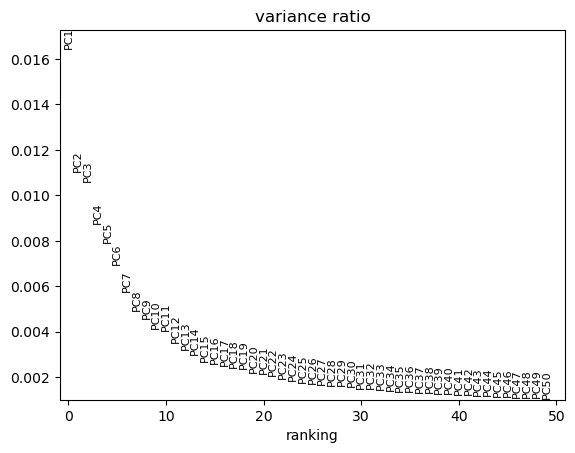

In [57]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=False)

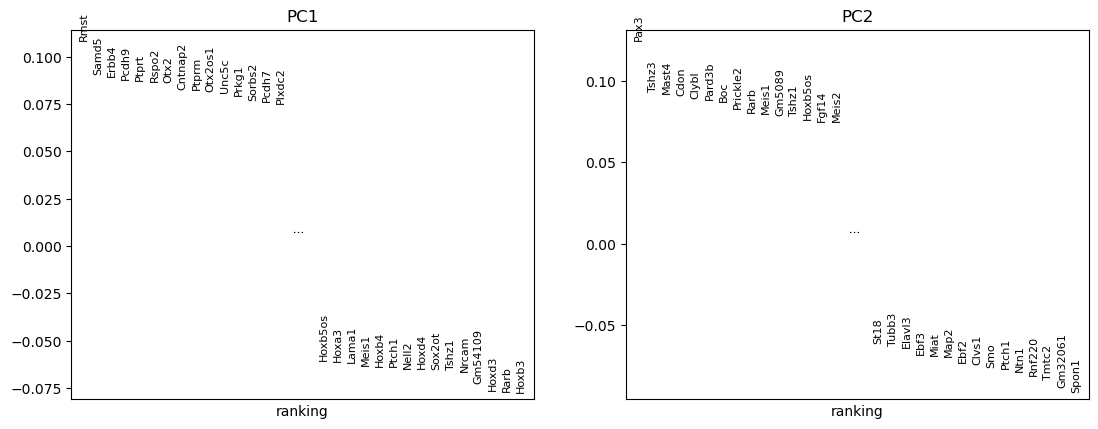

In [58]:
sc.pl.pca_loadings(adata, components = [1,2], show = True)

In [62]:
# Storing only the top 13 PCs and renaming variable for better identification
adata.obsm["X_pca_log1p"] = adata.obsm["X_pca"][:, :13]
del adata.obsm["X_pca"]

# Harmony Integrate with determined number of pc

In [ ]:
# Perform Harmony integration on log1p normalized data
sc.external.pp.harmony_integrate(adata, key="Library.ident", max_iter_harmony=20,  basis = "X_pca_log1p", adjusted_basis="X_pca_harmony_log1p")

2026-03-06 18:58:44,003 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-06 18:58:46,751 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-06 18:58:46,880 - harmonypy - INFO - Iteration 1 of 20
2026-03-06 18:58:54,514 - harmonypy - INFO - Iteration 2 of 20
2026-03-06 18:59:02,221 - harmonypy - INFO - Iteration 3 of 20
2026-03-06 18:59:09,813 - harmonypy - INFO - Iteration 4 of 20
2026-03-06 18:59:17,476 - harmonypy - INFO - Iteration 5 of 20
2026-03-06 18:59:24,991 - harmonypy - INFO - Iteration 6 of 20
2026-03-06 18:59:32,617 - harmonypy - INFO - Iteration 7 of 20
2026-03-06 18:59:35,394 - harmonypy - INFO - Converged after 7 iterations


In [67]:
adata 

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'hvg_log1p', 'mean', 'std'
    uns: 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'neighbors_log1p', 'pca'
    obsm: 'X_pca_harmony_log1p', 'X_umap_log1p', 'X_pca_log1p'
    varm: 'PCs'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'
    obsp: 'neighbors_log1p_connectivities', 'neighbors_log1p_distances'

# Neighbor Generation + Umap

In [ ]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony_log1p", key_added="neighbors_log1p")

/home/yubin/.conda/envs/scRNAseq_python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
sc.tl.umap(adata, neighbors_key="neighbors_log1p", key_added="X_umap_log1p")

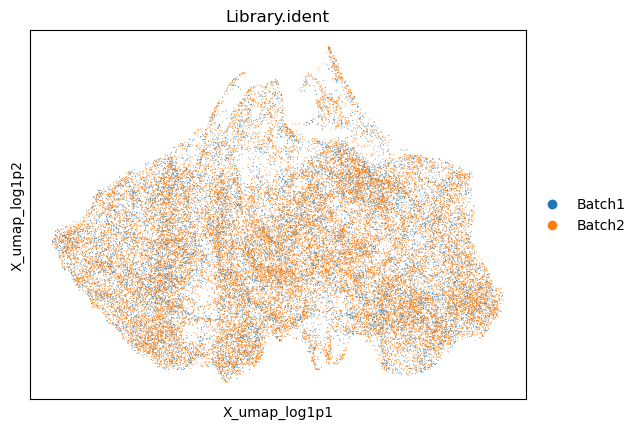

In [ ]:
sc.pl.embedding(adata, basis = "X_umap_log1p", color = "Library.ident", size = 2)

## Adding Celltype annnotation done by Katie


In [73]:
output_path_data = "/project/imoskowitz/kdreyer/projects_python/008_Hh_in_brain_dev/output_data_Smo_null/brain/"

adata_anno = sc.read_h5ad(output_path_data+"adata_anno_Zallen_neural_plate_E875_model_top1000_mv.h5ad")

In [7]:
adata_anno.obs

,orig.ident,nCount_RNA,nFeature_RNA,Condition,Library.ident,Sample,Replicate,percent.mt,nCount_SCT,nFeature_SCT,...,Zallen_neural_plate_E875_model_top1000_low_score,Zallen_neural_plate_E875_model_top1000_mv_label_mode_l025,Zallen_neural_plate_E875_model_top1000_mv_label_mode_l05,Zallen_neural_plate_E875_model_top1000_mv_label_mode_l10,Zallen_neural_plate_E875_model_top1000_mv_label_mode_l20,Zallen_neural_plate_E875_model_top1000_mv_label_mode_l30,Zallen_neural_plate_E875_model_top1000_mv_label_mode_l40,Zallen_neural_plate_E875_model_top1000_mv_label_mode_l50,background_cell,Celltype
Sample1_Control_rep1_AAACCAAAGAATCAAG-1,SeuratProject,3262.0,2142,Control,Batch1,Sample1,Rep1,0.122624,5329.0,2181,...,0.986041,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,True,Hindbrain
Sample1_Control_rep1_AAACCAAAGATTGACT-1,SeuratProject,3813.0,2414,Control,Batch1,Sample1,Rep1,0.078678,5227.0,2418,...,0.698986,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,True,Hindbrain
Sample1_Control_rep1_AAACCATTCAGCAGGA-1,SeuratProject,3538.0,2289,Control,Batch1,Sample1,Rep1,0.169587,5269.0,2306,...,0.999886,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,True,Midbrain
Sample1_Control_rep1_AAACCCGCAATGCCAG-1,SeuratProject,6732.0,3437,Control,Batch1,Sample1,Rep1,0.193108,6625.0,3437,...,0.818263,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,True,Hindbrain
Sample1_Control_rep1_AAACCCGCAGCACTTC-1,SeuratProject,9913.0,3927,Control,Batch1,Sample1,Rep1,0.221931,7060.0,3816,...,0.865601,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Midbrain,Hindbrain,True,Hindbrain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sample6_SmoNull_rep3_TGTGGTTGTGCGGCTT-1,SeuratProject,6998.0,3498,SmoNull,Batch2,Sample6,Rep3,0.114318,6740.0,3498,...,0.958716,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,True,Hindbrain
Sample6_SmoNull_rep3_TGTGTACGTCAAGTCT-1,SeuratProject,5143.0,2855,SmoNull,Batch2,Sample6,Rep3,0.019444,5457.0,2855,...,0.932315,Forebrain,Midbrain,Midbrain,Midbrain,Midbrain,Midbrain,Midbrain,True,Midbrain
Sample6_SmoNull_rep3_TGTGTACGTTCCGTTC-1,SeuratProject,3989.0,2491,SmoNull,Batch2,Sample6,Rep3,0.000000,5263.0,2492,...,0.999712,Forebrain,Forebrain,Forebrain,Forebrain,Forebrain,Forebrain,Forebrain,True,Forebrain
Sample6_SmoNull_rep3_TGTGTTGAGCAGGTAG-1,SeuratProject,4178.0,2632,SmoNull,Batch2,Sample6,Rep3,0.119674,5253.0,2632,...,0.303532,Forebrain,Midbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,Hindbrain,True,Forebrain


In [74]:
celltype = adata_anno.obs["Celltype"]

In [75]:
type(celltype)

pandas.core.series.Series

In [76]:
# merging adata with cell type
adata.obs = adata.obs.merge(celltype, how="outer", left_index=True, right_index=True)

### Checking Umap with celltype

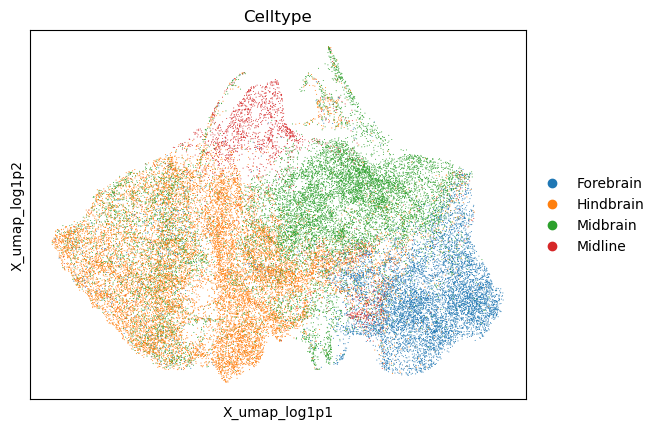

In [77]:
sc.pl.embedding(adata, basis = "X_umap_log1p", color = "Celltype", size = 2)

In [89]:
adata.write_h5ad("/project/imoskowitz/yubin/1-sc_practice/SmoNull_Brain_system.h5ad")